<a href="https://colab.research.google.com/github/springboardmentor1077k-prog/Vision-Extract-Isolation/blob/shivateja/week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Loaded previous weights successfully! Continuing training...
loading annotations into memory...
Done (t=0.61s)
creating index...
index created!
loading annotations into memory...
Done (t=0.62s)
creating index...
index created!

🚀 Training with SGD optimizer...
Epoch [1/5] - Loss: 0.7066
Epoch [2/5] - Loss: 0.6249
Epoch [3/5] - Loss: 0.6192
Epoch [4/5] - Loss: 0.5859
Epoch [5/5] - Loss: 0.5788
loading annotations into memory...
Done (t=0.71s)
creating index...
index created!
loading annotations into memory...
Done (t=0.98s)
creating index...
index created!
✅ Loaded previous weights successfully! Continuing training...
loading annotations into memory...
Done (t=0.69s)
creating index...
index created!
loading annotations into memory...
Done (t=0.80s)
creating index...
index created!

🚀 Training with Adam optimizer...
Epoch [1/5] - Loss: 0.7915
Epoch [2/5] - Loss: 0.6611
Epoch [3/5] - Loss: 0.6307
Epoch [4/5] - Loss: 0.5946
Epoch [5/5] - Loss: 0.5637
loading annotations into memory...
Do

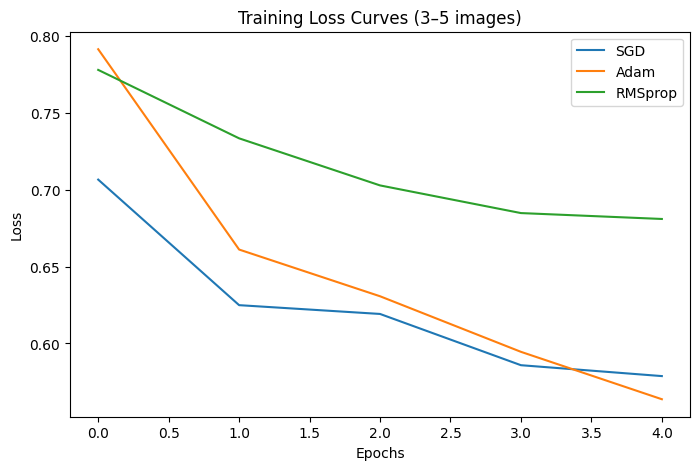

SGD ➤ IoU: 0.4341, Dice: 0.5896
Adam ➤ IoU: 0.3076, Dice: 0.4577
RMSprop ➤ IoU: 0.4007, Dice: 0.5699


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import cv2, os
from pycocotools.coco import COCO
from torchvision.datasets import CocoDetection

MODEL_PATH = "/content/drive/MyDrive/unet_trained.pth"

class COCOSegmentation(CocoDetection):
    def __init__(self, root, annFile, target_size=(128,128), max_images=5):
        super().__init__(root, annFile)
        self.coco = COCO(annFile)
        self.ids = list(sorted(self.coco.imgs.keys()))[:max_images]
        self.root = root
        self.target_size = target_size

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        path = self.coco.loadImgs(img_id)[0]['file_name']
        img = plt.imread(os.path.join(self.root, path))

        if len(img.shape) == 2:
            img = np.stack([img]*3, axis=-1)
        elif img.shape[2] == 4:
            img = img[:,:,:3]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        img = cv2.resize(img, self.target_size)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)

        img = TF.to_tensor(img)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        return img, mask

    def __len__(self):
        return len(self.ids)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.output_layer = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        b = self.bottleneck(p4)
        d4 = self.dec4(torch.cat((e4, self.upconv4(b)), dim=1))
        d3 = self.dec3(torch.cat((e3, self.upconv3(d4)), dim=1))
        d2 = self.dec2(torch.cat((e2, self.upconv2(d3)), dim=1))
        d1 = self.dec1(torch.cat((e1, self.upconv1(d2)), dim=1))
        return torch.sigmoid(self.output_layer(d1))

def train_model(optimizer_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet().to(device)
    if os.path.exists(MODEL_PATH):
       model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
       print("✅ Loaded previous weights successfully! Continuing training...")
    else:
         print("⚠️ No existing model found. Training from scratch.")
    criterion = nn.BCELoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)

    train_loader = DataLoader(COCOSegmentation(coco_root, coco_ann), batch_size=1, shuffle=True)

    train_losses = []
    print(f"\n🚀 Training with {optimizer_name} optimizer...")
    for epoch in range(5):
        epoch_loss = 0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/5] - Loss: {avg_loss:.4f}")
    return train_losses, model

def compute_metrics(model, loader):
    model.eval()
    ious, dices = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = (model(imgs) > 0.5).float()
            intersection = (preds * masks).sum()
            union = preds.sum() + masks.sum()
            dice = (2. * intersection) / (union + 1e-6)
            iou = intersection / (union - intersection + 1e-6)
            ious.append(iou.item())
            dices.append(dice.item())
    return np.mean(ious), np.mean(dices)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

coco_root = "drive/MyDrive/coco_data/val2017/val2017"
coco_ann = "drive/MyDrive/coco_data/annotations/annotations/instances_val2017.json"

optimizers = ["SGD", "Adam", "RMSprop"]
all_losses = {}
all_metrics = {}

for opt_name in optimizers:
    losses, model = train_model(opt_name)
    val_loader = DataLoader(COCOSegmentation(coco_root, coco_ann, max_images=3), batch_size=1)
    iou, dice = compute_metrics(model, val_loader)
    all_losses[opt_name] = losses
    all_metrics[opt_name] = (iou, dice)

plt.figure(figsize=(8,5))
for opt_name, losses in all_losses.items():
    plt.plot(losses, label=opt_name)
plt.title("Training Loss Curves (3–5 images)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

for opt, (iou, dice) in all_metrics.items():
    print(f"{opt} ➤ IoU: {iou:.4f}, Dice: {dice:.4f}")

Using device: cpu
loading annotations into memory...
Done (t=4.30s)
creating index...
index created!
loading annotations into memory...
Done (t=1.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.63s)
creating index...
index created!
loading annotations into memory...
Done (t=0.66s)
creating index...
index created!
✅ Loaded pre-trained model successfully.

🔹 Training with SGD optimizer
Epoch 1: Loss = 0.6936
Epoch 2: Loss = 0.6934
Epoch 3: Loss = 0.6929
Epoch 4: Loss = 0.6926
Epoch 5: Loss = 0.6920

🔹 Training with Adam optimizer
Epoch 1: Loss = 0.7174
Epoch 2: Loss = 0.7033
Epoch 3: Loss = 0.6939
Epoch 4: Loss = 0.6837
Epoch 5: Loss = 0.6786

🔹 Training with RMSprop optimizer
Epoch 1: Loss = 0.7421
Epoch 2: Loss = 0.7208
Epoch 3: Loss = 0.7184
Epoch 4: Loss = 0.7115
Epoch 5: Loss = 0.7053


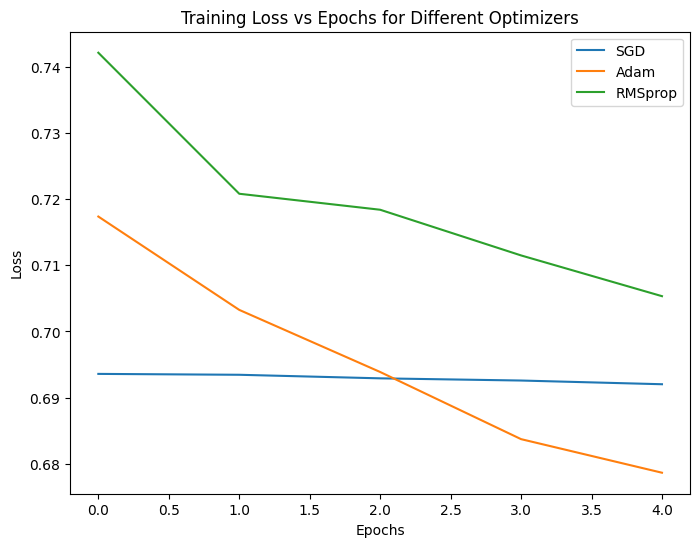


Average IoU: 0.44415283203125
Average Dice: 0.5421171903610229
✅ Model updated and saved successfully!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import numpy as np
from pycocotools.coco import COCO
import cv2, os, random

MODEL_PATH = "/content/drive/MyDrive/unet_trained.pth"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

coco_root = "drive/MyDrive/coco_data/val2017/val2017"
coco_ann = "drive/MyDrive/coco_data/annotations/annotations/instances_val2017.json"

class COCOSegmentation(CocoDetection):
    def __init__(self, root, annFile, target_size=(128,128), limit=5):
        super().__init__(root, annFile)
        self.coco = COCO(annFile)
        self.ids = list(sorted(self.coco.imgs.keys()))[:limit]
        self.target_size = target_size

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        path = self.coco.loadImgs(img_id)[0]['file_name']
        img = plt.imread(os.path.join(self.root, path))

        if len(img.shape) == 2:
            img = np.stack([img]*3, axis=-1)
        elif img.shape[2] == 4:
            img = img[:,:,:3]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        img = cv2.resize(img, self.target_size)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
        img = TF.to_tensor(img)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        return img, mask

    def __len__(self):
        return len(self.ids)

train_loader = DataLoader(COCOSegmentation(coco_root, coco_ann), batch_size=1, shuffle=True)
val_loader   = DataLoader(COCOSegmentation(coco_root, coco_ann), batch_size=1, shuffle=False)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.output_layer = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        b = self.bottleneck(p4)
        d4 = self.dec4(torch.cat((e4, self.upconv4(b)), dim=1))
        d3 = self.dec3(torch.cat((e3, self.upconv3(d4)), dim=1))
        d2 = self.dec2(torch.cat((e2, self.upconv2(d3)), dim=1))
        d1 = self.dec1(torch.cat((e1, self.upconv1(d2)), dim=1))
        return torch.sigmoid(self.output_layer(d1))


model = UNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
print("✅ Loaded pre-trained model successfully.")

criterion = nn.BCEWithLogitsLoss()

optimizers = {
    'SGD': optim.SGD(model.parameters(), lr=0.001, momentum=0.9),
    'Adam': optim.Adam(model.parameters(), lr=0.001),
    'RMSprop': optim.RMSprop(model.parameters(), lr=0.001)
}

def train_model(optimizer_name, optimizer):
    print(f"\n🔹 Training with {optimizer_name} optimizer")
    losses = []
    model.train()
    for epoch in range(5):  # 5 epochs per optimizer
        total_loss = 0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")
    return losses

all_losses = {}
for name, opt in optimizers.items():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    all_losses[name] = train_model(name, opt)

plt.figure(figsize=(8,6))
for name, losses in all_losses.items():
    plt.plot(losses, label=name)
plt.title("Training Loss vs Epochs for Different Optimizers")
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.legend(); plt.show()

def iou_score(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def dice_coef(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

model.eval()
ious, dices = [], []
with torch.no_grad():
    for img, mask in val_loader:
        img, mask = img.to(device), mask.to(device)
        pred = model(img)
        ious.append(iou_score(pred, mask).item())
        dices.append(dice_coef(pred, mask).item())

print("\nAverage IoU:", np.mean(ious))
print("Average Dice:", np.mean(dices))

torch.save(model.state_dict(), MODEL_PATH)
print("✅ Model updated and saved successfully!")


In [ ]:
import os

print(os.path.getsize("drive/MyDrive/unet_trained.pth"))

124235263


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import random
import matplotlib.pyplot as plt


def iou_score(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    intersection = (pred_bin * target).sum()
    union = pred_bin.sum() + target.sum() - intersection
    if union == 0:
        return 1.0
    return intersection / union

def dice_score(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    intersection = (pred_bin * target).sum()
    total = pred_bin.sum() + target.sum()
    if total == 0:
        return 1.0
    return (2 * intersection) / total

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_model(model, loader, device):
    model.eval()
    ious, dices = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            ious.append(iou_score(outputs, masks))
            dices.append(dice_score(outputs, masks))
    return np.mean(ious), np.mean(dices)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn = nn.BCELoss()


train_loader = DataLoader(COCOSegmentation(coco_root, coco_ann, target_size=(128,128)), batch_size=1, shuffle=True)
val_loader   = DataLoader(COCOSegmentation(coco_root, coco_ann, target_size=(128,128)), batch_size=1, shuffle=False)

learning_rates = [0.001, 0.0005, 0.002]
manual_results = {}

for lr in learning_rates:
    model = UNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"\n🔹 Training with learning rate = {lr}")
    for epoch in range(3):
        loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        print(f"Epoch {epoch+1}, Loss = {loss:.4f}")

    iou, dice = evaluate_model(model, val_loader, device)
    manual_results[lr] = (iou, dice)
    print(f"Validation IoU: {iou:.4f}, Dice: {dice:.4f}")

print("\n✅ Manual Search Results:")
for lr, (iou, dice) in manual_results.items():
    print(f"LR={lr}: IoU={iou:.4f}, Dice={dice:.4f}")

optimizers = ['Adam', 'SGD']
learning_rates = [0.001, 0.0005]
grid_results = {}

for opt_name in optimizers:
    for lr in learning_rates:
        model = UNet().to(device)
        if opt_name == 'Adam':
            optimizer = optim.Adam(model.parameters(), lr=lr)
        else:
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

        print(f"\n🔹 Grid Search: Optimizer={opt_name}, LR={lr}")
        for epoch in range(3):
            loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
            print(f"Epoch {epoch+1}, Loss={loss:.4f}")

        iou, dice = evaluate_model(model, val_loader, device)
        grid_results[(opt_name, lr)] = (iou, dice)
        print(f"Validation IoU={iou:.4f}, Dice={dice:.4f}")

print("\n✅ Grid Search Results:")
for (opt, lr), (iou, dice) in grid_results.items():
    print(f"{opt} + LR={lr}: IoU={iou:.4f}, Dice={dice:.4f}")

param_choices = {
    "optimizer": ["Adam", "SGD", "RMSprop"],
    "lr": [0.001, 0.0005, 0.002],
    "batch_size": [1, 2, 4]
}

def sample_random_config():
    return {
        "optimizer": random.choice(param_choices["optimizer"]),
        "lr": random.choice(param_choices["lr"]),
        "batch_size": random.choice(param_choices["batch_size"])
    }

random_results = {}

for i in range(5):
    cfg = sample_random_config()
    print(f"\n🔹 Random Search Trial {i+1}: {cfg}")

    train_loader = DataLoader(COCOSegmentation(coco_root, coco_ann, target_size=(128,128)), batch_size=cfg["batch_size"], shuffle=True)

    model = UNet().to(device)
    if cfg["optimizer"] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=cfg["lr"])
    elif cfg["optimizer"] == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=cfg["lr"], momentum=0.9)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=cfg["lr"])

    for epoch in range(3):
        loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        print(f"Epoch {epoch+1}, Loss={loss:.4f}")

    iou, dice = evaluate_model(model, val_loader, device)
    random_results[str(cfg)] = (iou, dice)
    print(f"Validation IoU={iou:.4f}, Dice={dice:.4f}")

print("\n✅ Random Search Results:")
for cfg, (iou, dice) in random_results.items():
    print(f"{cfg}: IoU={iou:.4f}, Dice={dice:.4f}")


loading annotations into memory...
Done (t=0.97s)
creating index...
index created!
loading annotations into memory...
Done (t=1.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.65s)
creating index...
index created!
loading annotations into memory...
Done (t=0.90s)
creating index...
index created!

🔹 Training with learning rate = 0.001
Epoch 1, Loss = 0.7126
Epoch 2, Loss = 0.6984
Epoch 3, Loss = 0.6512
Validation IoU: 0.2468, Dice: 0.3736

🔹 Training with learning rate = 0.0005
Epoch 1, Loss = 0.7321
Epoch 2, Loss = 0.6547
Epoch 3, Loss = 0.6195
Validation IoU: 0.0000, Dice: 0.0000

🔹 Training with learning rate = 0.002
Epoch 1, Loss = 0.7676
Epoch 2, Loss = 0.7306
Epoch 3, Loss = 0.6757
Validation IoU: 0.4410, Dice: 0.5442

✅ Manual Search Results:
LR=0.001: IoU=0.2468, Dice=0.3736
LR=0.0005: IoU=0.0000, Dice=0.0000
LR=0.002: IoU=0.4410, Dice=0.5442

🔹 Grid Search: Optimizer=Adam, LR=0.001
Epoch 1, Loss=0.7413
Epoch 2, Loss=0.6863
Epoch 3, Loss=0.6371

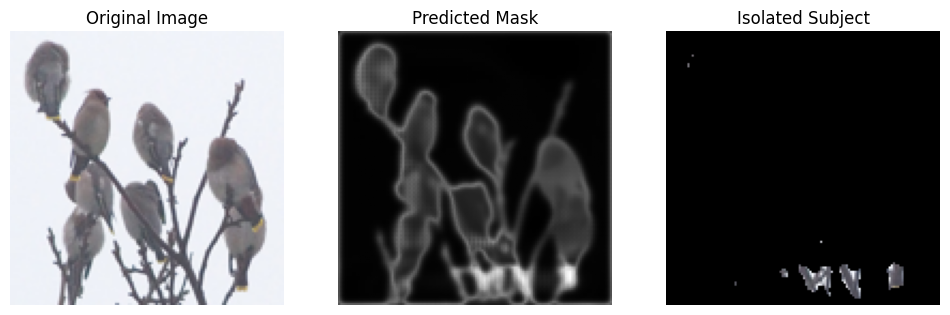

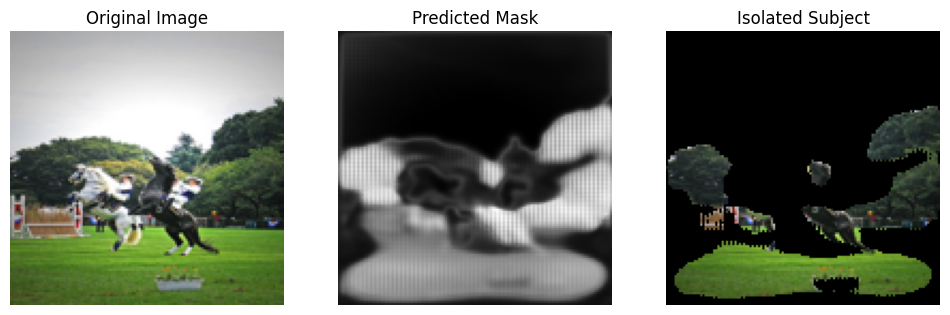

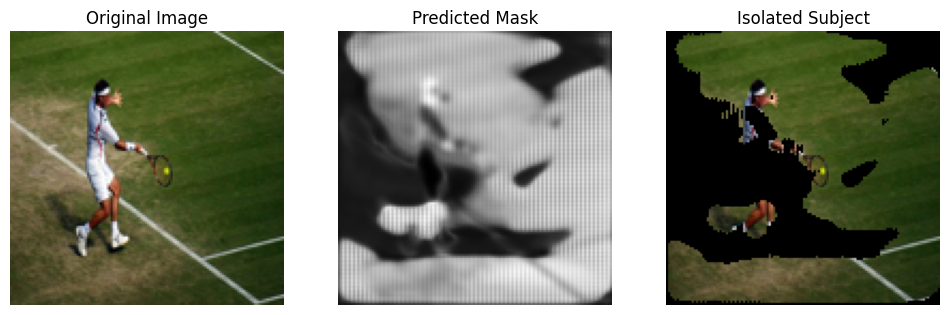

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
MODEL_PATH = "/content/drive/MyDrive/unet_trained.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

preprocess = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

test_images = [
    "sample1.jpg",
    "sample2.jpg",
    "sample3.jpg"
]

threshold = 0.5

for path in test_images:
    img = Image.open(path).convert("RGB")
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred_mask = torch.sigmoid(output).cpu().squeeze().numpy()

    pred_mask = (pred_mask - pred_mask.min()) / (pred_mask.max() - pred_mask.min() + 1e-8)

    binary_mask = (pred_mask > threshold).astype(np.uint8)

    img_np = np.array(img.resize((128, 128)))
    isolated = cv2.bitwise_and(img_np, img_np, mask=binary_mask)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(isolated)
    plt.title("Isolated Subject")
    plt.axis("off")

    plt.show()


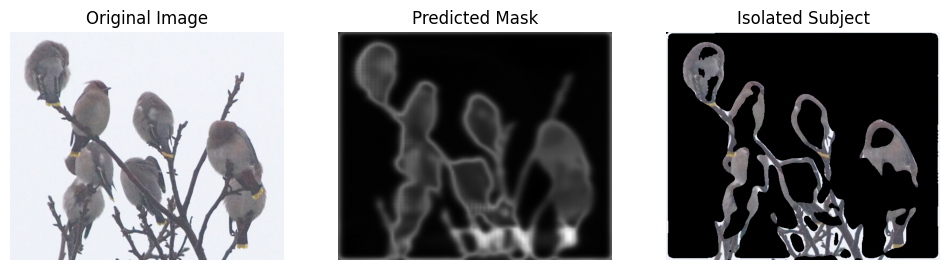

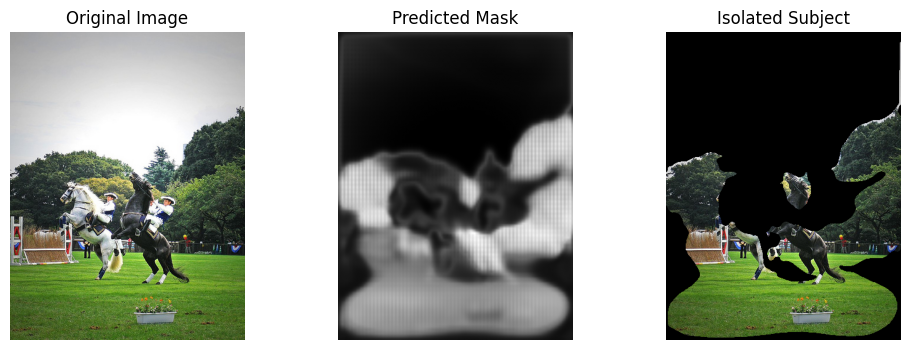

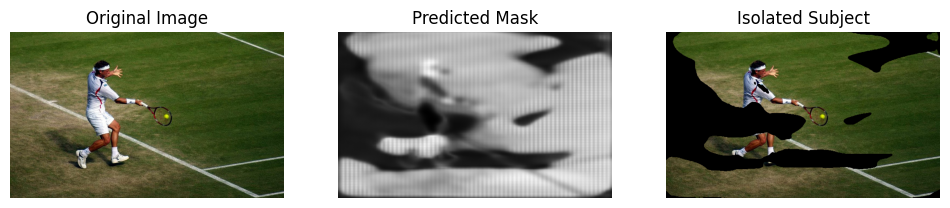

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
MODEL_PATH = "/content/drive/MyDrive/unet_trained.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

preprocess = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

test_images = [
    "sample1.jpg",
    "sample2.jpg",
    "sample3.jpg"
]

threshold = 0.25
for path in test_images:
    img = Image.open(path).convert("RGB")
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred_mask = torch.sigmoid(output).cpu().squeeze().numpy()

    pred_mask = (pred_mask - pred_mask.min()) / (pred_mask.max() - pred_mask.min() + 1e-8)

    pred_mask_resized = cv2.resize(pred_mask, (img.width, img.height))

    binary_mask = (pred_mask_resized > threshold).astype(np.uint8)

    binary_mask = cv2.medianBlur(binary_mask, 5)

    img_np = np.array(img)
    isolated = cv2.bitwise_and(img_np, img_np, mask=binary_mask)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(pred_mask_resized, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(isolated)
    plt.title("Isolated Subject")
    plt.axis("off")

    plt.show()


✅ Model loaded successfully on cpu


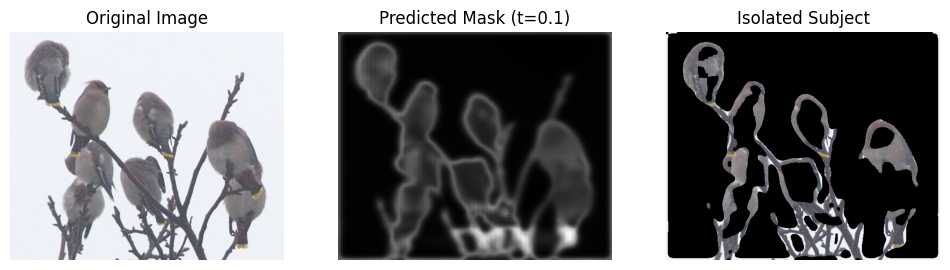

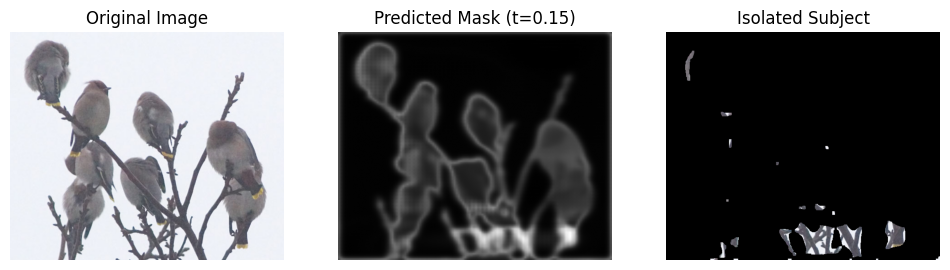

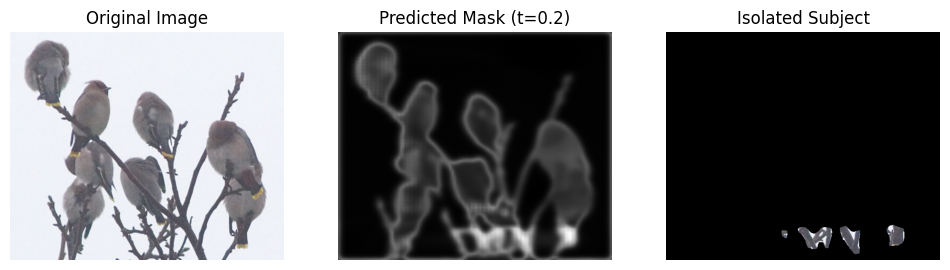

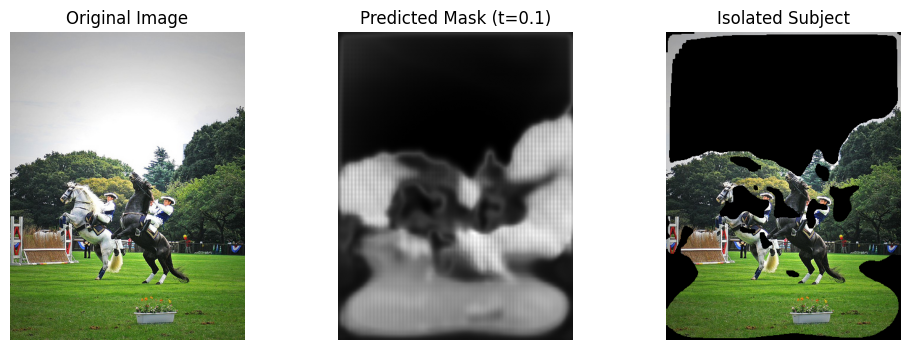

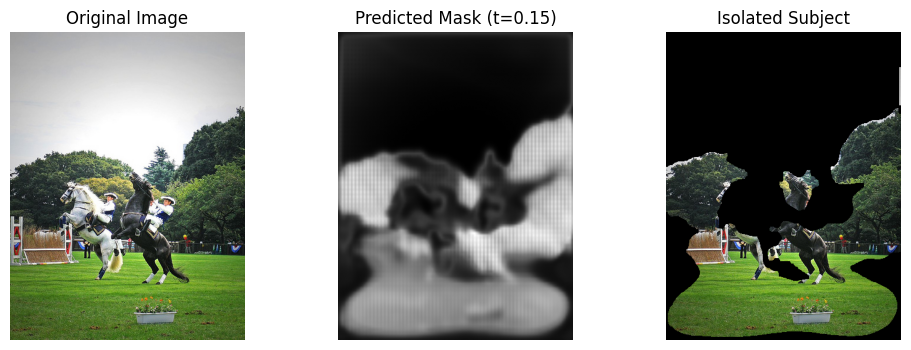

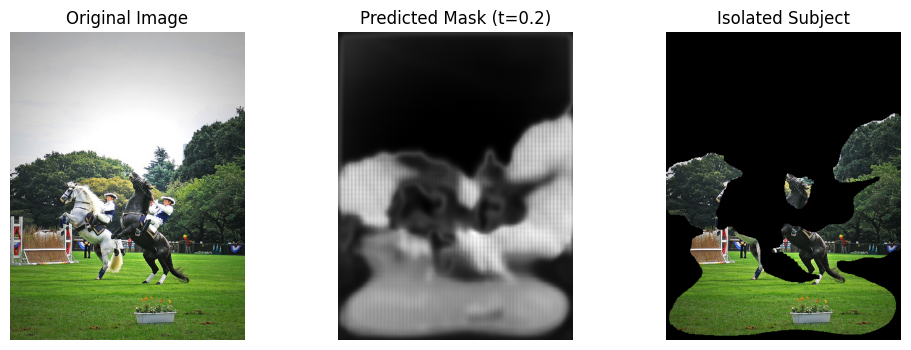

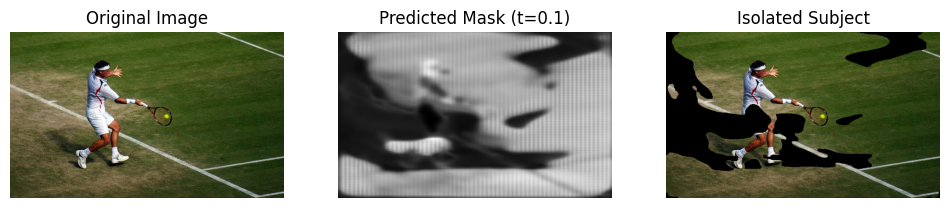

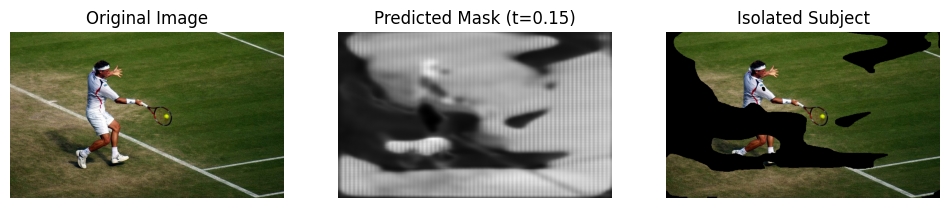

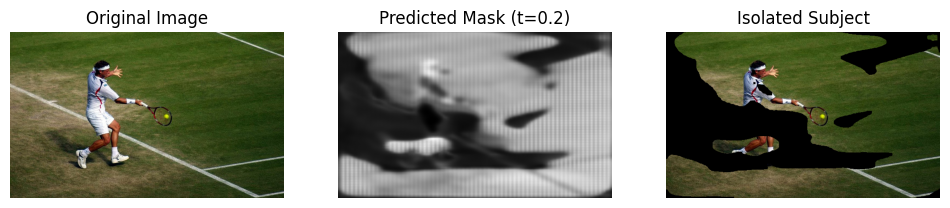

In [ ]:
import torch, cv2, numpy as np, matplotlib.pyplot as plt
from torchvision import transforms
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = conv_block(512, 1024)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = conv_block(128, 64)
        self.output_layer = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        b = self.bottleneck(p4)
        d4 = self.dec4(torch.cat((e4, self.upconv4(b)), dim=1))
        d3 = self.dec3(torch.cat((e3, self.upconv3(d4)), dim=1))
        d2 = self.dec2(torch.cat((e2, self.upconv2(d3)), dim=1))
        d1 = self.dec1(torch.cat((e1, self.upconv1(d2)), dim=1))
        return torch.sigmoid(self.output_layer(d1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
MODEL_PATH = "/content/drive/MyDrive/unet_trained.pth"  # update if different
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("✅ Model loaded successfully on", device)

def preprocess_image(img_path, target_size=(128,128)):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, target_size)
    tensor_img = transforms.ToTensor()(img_resized).unsqueeze(0).to(device)
    return img_rgb, img_resized, tensor_img

test_images = [
    "sample1.jpg",
    "sample2.jpg",
    "sample3.jpg"
]

for img_path in test_images:
    img_rgb, img_resized, tensor_img = preprocess_image(img_path)

    with torch.no_grad():
        pred_mask = model(tensor_img).cpu().squeeze().numpy()
    pred_mask_resized = cv2.resize(pred_mask, (img_rgb.shape[1], img_rgb.shape[0]))

    thresholds = [0.1, 0.15, 0.2]
    for t in thresholds:
        binary_mask = (pred_mask_resized > t).astype(np.uint8) * 255

        kernel = np.ones((5,5), np.uint8)
        processed_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
        processed_mask = cv2.morphologyEx(processed_mask, cv2.MORPH_CLOSE, kernel)

        isolated = cv2.bitwise_and(img_rgb, img_rgb, mask=processed_mask)

        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title("Original Image"); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(pred_mask_resized, cmap='gray'); plt.title(f"Predicted Mask (t={t})"); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(isolated); plt.title("Isolated Subject"); plt.axis('off')
        plt.show()


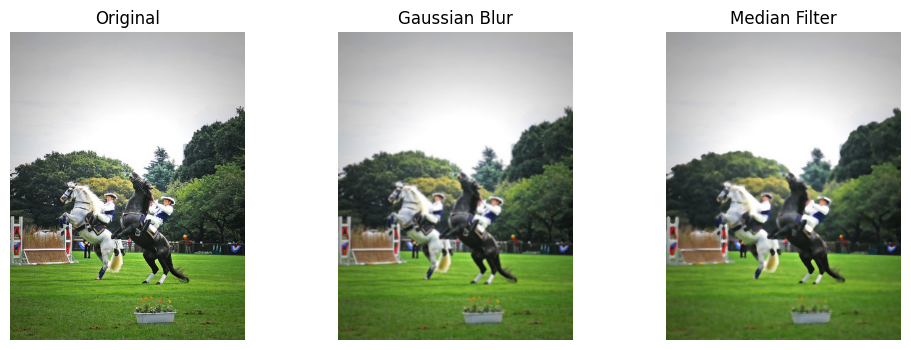

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("sample2.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gaussian = cv2.GaussianBlur(img, (5, 5), 0)

median = cv2.medianBlur(img, 5)


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Gaussian Blur")
plt.imshow(gaussian)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Median Filter")
plt.imshow(median)
plt.axis("off")

plt.show()


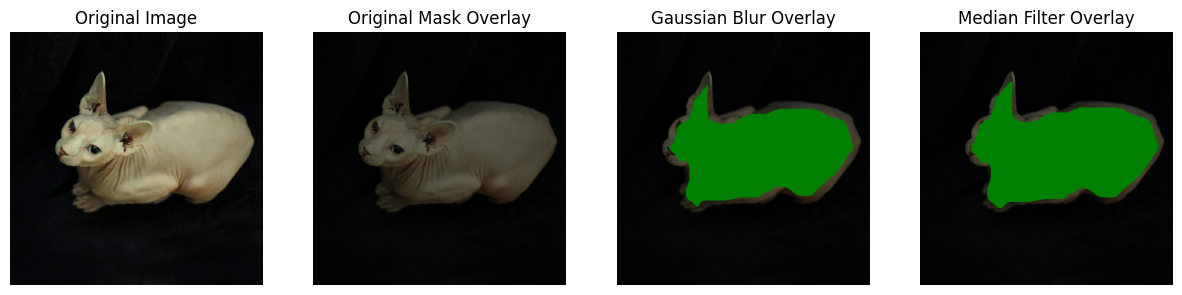

In [ ]:
import tensorflow_datasets as tfds
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset, info = tfds.load('oxford_iiit_pet:4.0.0', split='train', with_info=True)
dataset = dataset.take(1)

for sample in dataset:
    image = sample['image'].numpy()
    mask = sample['segmentation_mask'].numpy()[:, :, 0]

gaussian_mask = cv2.GaussianBlur(mask.astype(np.float32), (7, 7), 0)
median_mask = cv2.medianBlur(mask.astype(np.uint8), 7)


_, gaussian_mask_bin = cv2.threshold(gaussian_mask, 1, 255, cv2.THRESH_BINARY)
_, median_mask_bin = cv2.threshold(median_mask, 1, 255, cv2.THRESH_BINARY)

mask_bin = (mask > 0).astype(np.uint8) * 255

def overlay_mask(image, binary_mask, color=(0, 255, 0), alpha=0.5):
    if binary_mask.shape[:2] != image.shape[:2]:
        binary_mask = cv2.resize(binary_mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

    color_overlay = np.zeros_like(image, dtype=np.uint8)
    color_overlay[:] = color

    foreground = cv2.bitwise_and(image, image, mask=binary_mask)
    background = cv2.bitwise_and(color_overlay, color_overlay, mask=cv2.bitwise_not(binary_mask))

    overlay = cv2.addWeighted(foreground, 1 - alpha, background, alpha, 0)
    return overlay


overlay_original = overlay_mask(image, mask_bin)
overlay_gaussian = overlay_mask(image, gaussian_mask_bin.astype(np.uint8))
overlay_median = overlay_mask(image, median_mask_bin)


plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Original Mask Overlay")
plt.imshow(overlay_original)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Gaussian Blur Overlay")
plt.imshow(overlay_gaussian)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Median Filter Overlay")
plt.imshow(overlay_median)
plt.axis("off")

plt.show()